<a href="https://colab.research.google.com/github/thedaerklord/ms-sys-takeover.github.io/blob/main/Emerging_Technology.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Machine Learning**

**1. Upload the CSV zip file**

In [2]:
from google.colab import files

# Upload the CSV file
uploaded = files.upload()


Saving archive.zip to archive.zip


**2. Verify the Filename**

In [21]:
# List the uploaded files
uploaded.keys()


dict_keys([])

**3. Unzip the File**

In [22]:
import zipfile

# Specify the zip file name
zip_file = 'archive.zip'

# Extract the zip file
with zipfile.ZipFile(zip_file, 'r') as zip_ref:
    zip_ref.extractall()

# List the files to verify extraction
import os
os.listdir()


['.config',
 'archive.zip',
 'Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv',
 'sample_data']

**Data Collection**

In [23]:
# Loading the CSV file into a Pandas DataFrame
import pandas as pd

csv_filename = 'Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv'
df = pd.read_csv(csv_filename)

# Display the first few rows of the data
df.head()


,Flow ID,Source IP,Source Port,Destination IP,Destination Port,Protocol,Timestamp,Flow Duration,Total Fwd Packets,Total Backward Packets,...,min_seg_size_forward,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Label
0,192.168.10.5-104.16.207.165-54865-443-6,104.16.207.165,443,192.168.10.5,54865,6,7/7/2017 3:30,3,2,0,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
1,192.168.10.5-104.16.28.216-55054-80-6,104.16.28.216,80,192.168.10.5,55054,6,7/7/2017 3:30,109,1,1,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
2,192.168.10.5-104.16.28.216-55055-80-6,104.16.28.216,80,192.168.10.5,55055,6,7/7/2017 3:30,52,1,1,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
3,192.168.10.16-104.17.241.25-46236-443-6,104.17.241.25,443,192.168.10.16,46236,6,7/7/2017 3:30,34,1,1,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
4,192.168.10.5-104.19.196.102-54863-443-6,104.19.196.102,443,192.168.10.5,54863,6,7/7/2017 3:30,3,2,0,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN


**4. Data Cleaning**

In [24]:
# Strip leading and trailing spaces from column names
df.columns = df.columns.str.strip()

# Check for missing values
print("Missing values before cleaning:")
print(df.isnull().sum())

# Fill missing values with the mean for numerical columns
df.fillna(df.mean(numeric_only=True), inplace=True)

# Drop rows with missing values in the 'Label' column
df.dropna(subset=['Label'], inplace=True)

# Verify the cleaned dataset
print("Cleaned data:")
print(df.head())


Missing values before cleaning:
Flow ID             0
Source IP           0
Source Port         0
Destination IP      0
Destination Port    0
                   ..
Idle Mean           0
Idle Std            0
Idle Max            0
Idle Min            0
Label               0
Length: 85, dtype: int64
Cleaned data:
                                   Flow ID       Source IP  Source Port  \
0  192.168.10.5-104.16.207.165-54865-443-6  104.16.207.165          443   
1    192.168.10.5-104.16.28.216-55054-80-6   104.16.28.216           80   
2    192.168.10.5-104.16.28.216-55055-80-6   104.16.28.216           80   
3  192.168.10.16-104.17.241.25-46236-443-6   104.17.241.25          443   
4  192.168.10.5-104.19.196.102-54863-443-6  104.19.196.102          443   

  Destination IP  Destination Port  Protocol      Timestamp  Flow Duration  \
0   192.168.10.5             54865         6  7/7/2017 3:30              3   
1   192.168.10.5             55054         6  7/7/2017 3:30            109   
2 

**4. Data Preprocessing**

**a. Normalization**

In [25]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler

# Load the dataset
df = pd.read_csv('Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv')

# Identify numerical columns
numerical_cols = df.select_dtypes(include=['float64', 'int64']).columns

# Check for NaN values
nan_values = df[numerical_cols].isnull().sum()
print("Count of NaN Values per Column:")
print(nan_values)

# Fill NaN values (mean imputation)
df[numerical_cols] = df[numerical_cols].fillna(df[numerical_cols].mean())

# Check for Infinity values
inf_values = df[numerical_cols].replace([np.inf, -np.inf], np.nan).isnull().sum()
print("\nCount of Infinity Values per Column:")
print(inf_values)

# Replace infinity values with NaNs, then fill NaNs again
df[numerical_cols] = df[numerical_cols].replace([np.inf, -np.inf], np.nan)
df[numerical_cols] = df[numerical_cols].fillna(df[numerical_cols].mean())

# Normalize the numerical columns
scaler = MinMaxScaler()
df[numerical_cols] = scaler.fit_transform(df[numerical_cols])

# Display a snippet of the normalized data
print("\nNormalized Data:")
print(df.head())


Count of NaN Values per Column:
 Source Port          0
 Destination Port     0
 Protocol             0
 Flow Duration        0
 Total Fwd Packets    0
                     ..
 Active Min           0
Idle Mean             0
 Idle Std             0
 Idle Max             0
 Idle Min             0
Length: 80, dtype: int64

Count of Infinity Values per Column:
 Source Port          0
 Destination Port     0
 Protocol             0
 Flow Duration        0
 Total Fwd Packets    0
                     ..
 Active Min           0
Idle Mean             0
 Idle Std             0
 Idle Max             0
 Idle Min             0
Length: 80, dtype: int64

Normalized Data:
                                   Flow ID       Source IP   Source Port  \
0  192.168.10.5-104.16.207.165-54865-443-6  104.16.207.165      0.006760   
1    192.168.10.5-104.16.28.216-55054-80-6   104.16.28.216      0.001221   
2    192.168.10.5-104.16.28.216-55055-80-6   104.16.28.216      0.001221   
3  192.168.10.16-104.17.241.25

**b. Categorical Encoding**

In [26]:
import pandas as pd

# Load the dataset
df = pd.read_csv('Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv')

# Select categorical columns
categorical_cols = df.select_dtypes(include=['object']).columns

# Ensure to handle NaNs in categorical columns
df[categorical_cols] = df[categorical_cols].fillna('Missing')

# Limit the number of categories to reduce memory usage
for col in categorical_cols:
    top_categories = df[col].value_counts().index[:10]  # Keep top 10 most frequent categories
    df[col] = df[col].apply(lambda x: x if x in top_categories else 'Other')

# Apply one-hot encoding with get_dummies
df_encoded = pd.get_dummies(df, columns=categorical_cols, drop_first=True)  # No need for sparse format

# Display a snippet of the encoded data
print("\nEncoded Data:")
print(df_encoded.head())



Encoded Data:
    Source Port   Destination Port   Protocol   Flow Duration  \
0           443              54865          6               3   
1            80              55054          6             109   
2            80              55055          6              52   
3           443              46236          6              34   
4           443              54863          6               3   

    Total Fwd Packets   Total Backward Packets  Total Length of Fwd Packets  \
0                   2                        0                           12   
1                   1                        1                            6   
2                   1                        1                            6   
3                   1                        1                            6   
4                   2                        0                           12   

    Total Length of Bwd Packets   Fwd Packet Length Max  \
0                             0                       6   
1

**5. Data Visualization**

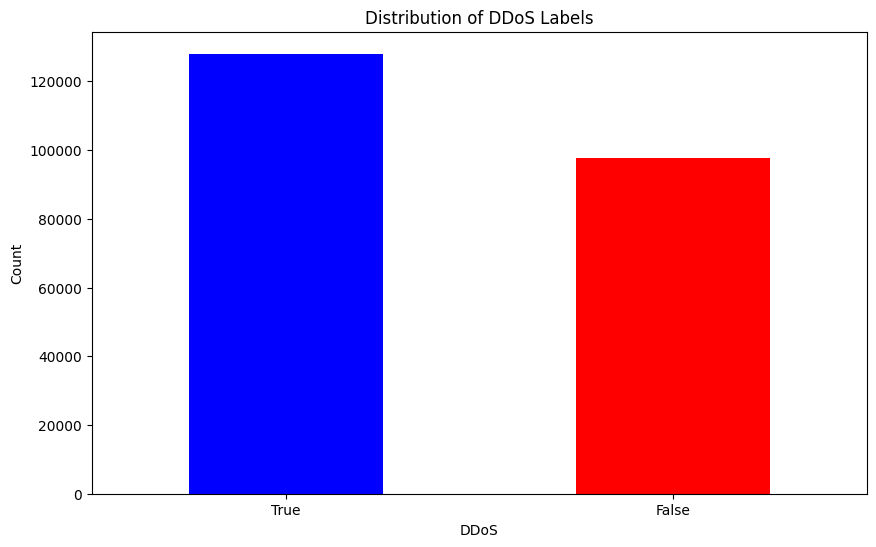

In [27]:
# Strip any leading/trailing whitespace from column names
df_encoded.columns = df_encoded.columns.str.strip()

# Check if 'Label_DDoS' exists after stripping whitespace
if 'Label_DDoS' in df_encoded.columns:
    # Count occurrences of each label
    label_counts = df_encoded['Label_DDoS'].value_counts()

    # Plotting the distribution of DDoS labels
    plt.figure(figsize=(10, 6))
    label_counts.plot(kind='bar', color=['blue', 'red'])
    plt.title('Distribution of DDoS Labels')
    plt.xlabel('DDoS')
    plt.ylabel('Count')
    plt.xticks(rotation=0)
    plt.show()
else:
    print("'Label_DDoS' column is not found in the DataFrame.")


**6. Feature Engineering**

In [28]:
# Assuming df_encoded is your DataFrame with encoded features and the target variable 'Label'

# Example feature engineering step: Create a new feature 'Total Packet Count'
df_encoded['Total Packet Count'] = df_encoded['Fwd Packets/s'] + df_encoded['Bwd Packets/s']

# Display updated feature set
print("Feature Engineering:")
print(df_encoded.head())


Feature Engineering:
   Source Port  Destination Port  Protocol  Flow Duration  Total Fwd Packets  \
0          443             54865         6              3                  2   
1           80             55054         6            109                  1   
2           80             55055         6             52                  1   
3          443             46236         6             34                  1   
4          443             54863         6              3                  2   

   Total Backward Packets  Total Length of Fwd Packets  \
0                       0                           12   
1                       1                            6   
2                       1                            6   
3                       1                            6   
4                       0                           12   

   Total Length of Bwd Packets  Fwd Packet Length Max  Fwd Packet Length Min  \
0                            0                      6                

**7. Model Selection**

In [30]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier

# Initialize the models
log_reg_model = LogisticRegression()  # Logistic Regression model for binary classification
decision_tree_model = DecisionTreeClassifier()  # Decision Tree model for complex relationships

# The decision here would depend on exploring the data further. You could start with Logistic Regression if you expect linearity,
# and switch to Decision Tree if you find the relationships in your data more complex.


**8. Model Training**

**1. Split Data and Train Model**

In [55]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report, confusion_matrix
import numpy as np

# Load and clean data
# Assuming 'df' is your DataFrame
df = pd.read_csv('Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv')

# Remove leading spaces from column names
df.columns = df.columns.str.strip()

# Define features (X) and the target variable (y)
X = df.drop(['Label', 'Flow ID', 'Source IP', 'Destination IP', 'Timestamp'], axis=1)
y = df['Label']

# Handle infinity values and very large values
X.replace([np.inf, -np.inf], np.nan, inplace=True)  # Replace infinities with NaN

# Impute missing values if any
X.ffill(inplace=True)  # Forward fill
X.bfill(inplace=True)  # Backward fill

# Convert categorical columns to numerical if necessary
# Example: Encoding 'Protocol' column
X = pd.get_dummies(X, columns=['Protocol'])

# Check if 'Label' contains NaN and handle if needed
print(f"Checking for NaN values in y: {y.isna().sum()}")

# Check class distribution
print("Class distribution in the full dataset:")
print(y.value_counts())

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Scale the features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Initialize and train Logistic Regression model
log_reg_model = LogisticRegression(max_iter=1000)  # Increased iterations
log_reg_model.fit(X_train_scaled, y_train)

# Predict and evaluate Logistic Regression model
y_pred_log_reg = log_reg_model.predict(X_test_scaled)
print("Logistic Regression Evaluation:")
print(confusion_matrix(y_test, y_pred_log_reg))
print(classification_report(y_test, y_pred_log_reg))

# Initialize and train Decision Tree model
decision_tree_model = DecisionTreeClassifier()
decision_tree_model.fit(X_train, y_train)

# Predict and evaluate Decision Tree model
y_pred_tree = decision_tree_model.predict(X_test)
print("Decision Tree Evaluation:")
print(confusion_matrix(y_test, y_pred_tree))
print(classification_report(y_test, y_pred_tree))

# Check class distribution in the training and testing sets
print("Class distribution in the training set:")
print(y_train.value_counts())

print("Class distribution in the testing set:")
print(y_test.value_counts())


Checking for NaN values in y: 0
Class distribution in the full dataset:
Label
DDoS      128027
BENIGN     97718
Name: count, dtype: int64
Logistic Regression Evaluation:
[[19514    30]
 [   24 25581]]
              precision    recall  f1-score   support

      BENIGN       1.00      1.00      1.00     19544
        DDoS       1.00      1.00      1.00     25605

    accuracy                           1.00     45149
   macro avg       1.00      1.00      1.00     45149
weighted avg       1.00      1.00      1.00     45149

Decision Tree Evaluation:
[[19541     3]
 [    3 25602]]
              precision    recall  f1-score   support

      BENIGN       1.00      1.00      1.00     19544
        DDoS       1.00      1.00      1.00     25605

    accuracy                           1.00     45149
   macro avg       1.00      1.00      1.00     45149
weighted avg       1.00      1.00      1.00     45149

Class distribution in the training set:
Label
DDoS      102422
BENIGN     78174
Name: co

**9. Model Evaluation**

In [60]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report, confusion_matrix
import numpy as np

# Load and clean data
df = pd.read_csv('Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv')

# Remove leading spaces from column names
df.columns = df.columns.str.strip()

# Define features (X) and the target variable (y)
X = df.drop(['Label', 'Flow ID', 'Source IP', 'Destination IP', 'Timestamp'], axis=1)
y = df['Label']

# Handle infinity values and very large values
X.replace([np.inf, -np.inf], np.nan, inplace=True)  # Replace infinities with NaN

# Impute missing values if any
X.ffill(inplace=True)  # Forward fill
X.bfill(inplace=True)  # Backward fill

# Convert categorical columns to numerical if necessary
X = pd.get_dummies(X, columns=['Protocol'])

# Check if 'Label' contains NaN and handle if needed
print(f"Checking for NaN values in y: {y.isna().sum()}")

# Check class distribution
print("Class distribution in the full dataset:")
print(y.value_counts())

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Scale the features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Initialize and train Logistic Regression model
log_reg_model = LogisticRegression(max_iter=1000)  # Increased iterations
log_reg_model.fit(X_train_scaled, y_train)

# Predict and evaluate Logistic Regression model
y_pred_log_reg = log_reg_model.predict(X_test_scaled)

# Print Logistic Regression evaluation metrics
print("Logistic Regression Evaluation:")
print(confusion_matrix(y_test, y_pred_log_reg))
print(classification_report(y_test, y_pred_log_reg))

# Initialize and train Decision Tree model
decision_tree_model = DecisionTreeClassifier()
decision_tree_model.fit(X_train, y_train)

# Predict and evaluate Decision Tree model
y_pred_tree = decision_tree_model.predict(X_test)

# Print Decision Tree evaluation metrics
print("Decision Tree Evaluation:")
print(confusion_matrix(y_test, y_pred_tree))
print(classification_report(y_test, y_pred_tree))

# Interpret results
# You can add additional analysis or visualization here if needed


Checking for NaN values in y: 0
Class distribution in the full dataset:
Label
DDoS      128027
BENIGN     97718
Name: count, dtype: int64
Logistic Regression Evaluation:
[[19514    30]
 [   24 25581]]
              precision    recall  f1-score   support

      BENIGN       1.00      1.00      1.00     19544
        DDoS       1.00      1.00      1.00     25605

    accuracy                           1.00     45149
   macro avg       1.00      1.00      1.00     45149
weighted avg       1.00      1.00      1.00     45149

Decision Tree Evaluation:
[[19542     2]
 [    2 25603]]
              precision    recall  f1-score   support

      BENIGN       1.00      1.00      1.00     19544
        DDoS       1.00      1.00      1.00     25605

    accuracy                           1.00     45149
   macro avg       1.00      1.00      1.00     45149
weighted avg       1.00      1.00      1.00     45149

